In [13]:
import pandas as pd

df = pd.read_csv('/content/food.csv')

df_food = df.copy()
df_food.head()

,Unnamed: 0,f_id,item,veg_or_non_veg
0,0,fd0,Aloo Tikki Burger,Veg
1,1,fd1,Veg Creamy Burger,Veg
2,2,fd2,Cheese Burst Burger,Veg
3,3,fd3,Paneer Creamy Burger,Veg
4,4,fd4,Maxican Burger,Veg


In [14]:
df_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371561 entries, 0 to 371560
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Unnamed: 0      371561 non-null  int64 
 1   f_id            371561 non-null  object
 2   item            371560 non-null  object
 3   veg_or_non_veg  371560 non-null  object
dtypes: int64(1), object(3)
memory usage: 11.3+ MB


In [15]:
df_food.columns

Index(['Unnamed: 0', 'f_id', 'item', 'veg_or_non_veg'], dtype='object')

In [16]:
df_food[df_food.isnull().any(axis=1)]

,Unnamed: 0,f_id,item,veg_or_non_veg
166711,166711,fd413746,NaN,NaN


In [17]:
df_food.isnull().sum()

,0
Unnamed: 0,0
f_id,0
item,1
veg_or_non_veg,1


In [18]:
df_food['veg_or_non_veg'].unique()

array(['Veg', 'Non-veg', nan], dtype=object)

In [19]:
df_food['veg_or_non_veg'].value_counts()

,count
veg_or_non_veg,
Veg,270776
Non-veg,100784


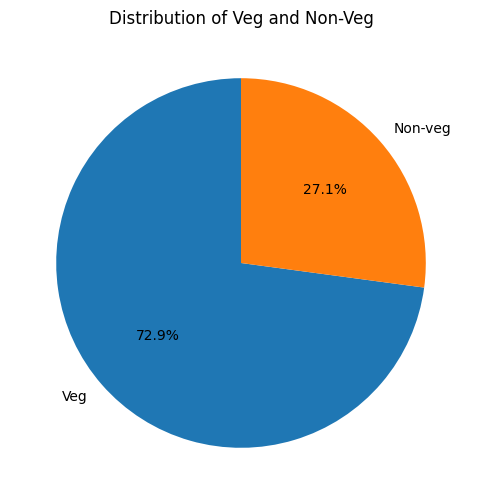

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

veg_counts = df_food['veg_or_non_veg'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))  # Adjust figure size if needed
plt.pie(veg_counts, labels=veg_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Veg and Non-Veg')
plt.show()

In [22]:
df_menu = pd.read_csv('/content/menu.csv')
df_menu.head()

,Unnamed: 0,menu_id,r_id,f_id,cuisine,price
0,0,mn0,567335.0,fd0,"Beverages,Pizzas",40.0
1,1,mn0,567335.0,fd669322,"Beverages,Pizzas",40.0
2,2,mn328,158203.0,fd0,Beverages,65.0
3,3,mn328,158203.0,fd669322,Beverages,65.0
4,4,mn449,158203.0,fd0,Beverages,65.0


In [23]:
df_menu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251051 entries, 0 to 251050
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  251051 non-null  int64  
 1   menu_id     251051 non-null  object 
 2   r_id        251050 non-null  float64
 3   f_id        251050 non-null  object 
 4   cuisine     251050 non-null  object 
 5   price       251050 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 11.5+ MB


In [24]:
df_menu.columns

Index(['Unnamed: 0', 'menu_id', 'r_id', 'f_id', 'cuisine', 'price'], dtype='object')

In [25]:
df_menu.isnull().sum()

,0
Unnamed: 0,0
menu_id,0
r_id,1
f_id,1
cuisine,1
price,1


In [26]:
df_menu['cuisine'].unique()

array(['Beverages,Pizzas', 'Beverages', 'Continental', 'Juices,Beverages',
       'Indian', 'Pizzas,Beverages', 'Chinese,Pizzas',
       'North Indian,Fast Food', 'Bakery,Beverages', 'Bakery,Pizzas',
       'Pizzas,Pastas', 'Pizzas,Snacks', 'Indian,Chinese',
       'Beverages,Fast Food', 'Burgers,Street Food', 'Pizzas,Burgers',
       'North Indian,Lucknowi', 'Fast Food,Pizzas', 'American,Pizzas',
       'Bakery,Indian', 'North Indian,Chinese', 'Chinese,Fast Food',
       'Chinese,Desserts', 'Italian,Beverages', 'Indian,Continental',
       'Italian', 'Desserts,Sweets', 'Indian,Fast Food',
       'Chinese,South Indian', 'Street Food,Snacks', 'Fast Food',
       'Maharashtrian,North Indian', 'Snacks,Fast Food',
       'Street Food,Fast Food', 'Bakery,Continental', 'Snacks',
       'Fast Food,Beverages', 'American,Snacks', 'Italian,Fast Food',
       'Ice Cream,American', 'Pan-Asian,Chinese', 'Fast Food,Snacks',
       'Snacks,Italian', 'Italian-American,Fast Food', 'Italian,Chinese',
  

In [27]:
df_menu['cuisine'].value_counts()

,count
cuisine,
"North Indian,Chinese",27435
"Indian,Chinese",17720
North Indian,14677
Indian,11110
"Chinese,North Indian",7961
...,...
"Maharashtrian,Fast Food",1
"Kebabs,Snacks",1
"South Indian,Hyderabadi",1


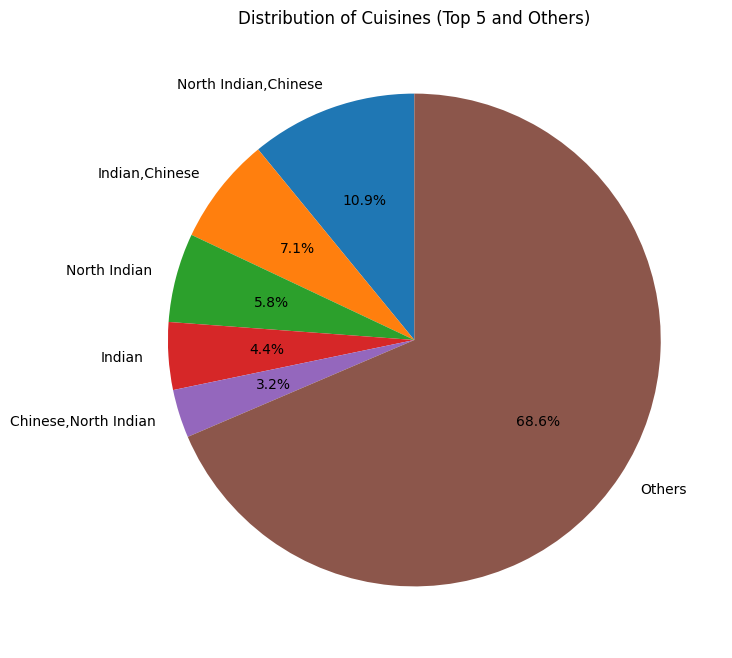

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Get value counts for 'cuisine'
cuisine_counts = df_menu['cuisine'].value_counts()

# Select top 5 cuisines and group the rest as "Others"
top_5_cuisines = cuisine_counts[:5]
other_cuisines_count = cuisine_counts[5:].sum()

# Combine top 5 and "Others" for the pie chart
# Use pd.concat instead of append
pie_chart_data = pd.concat([top_5_cuisines, pd.Series([other_cuisines_count], index=['Others'])])

# Create the pie chart
plt.figure(figsize=(8, 8))  # Adjust figure size if needed
plt.pie(pie_chart_data, labels=pie_chart_data.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Cuisines (Top 5 and Others)')
plt.show()

In [29]:
df_menu['price'].value_counts()

,count
price,
120.00,9041
100.00,8096
80.00,7960
150.00,7586
90.00,7205
...,...
161.25,1
116.67,1
421.00,1


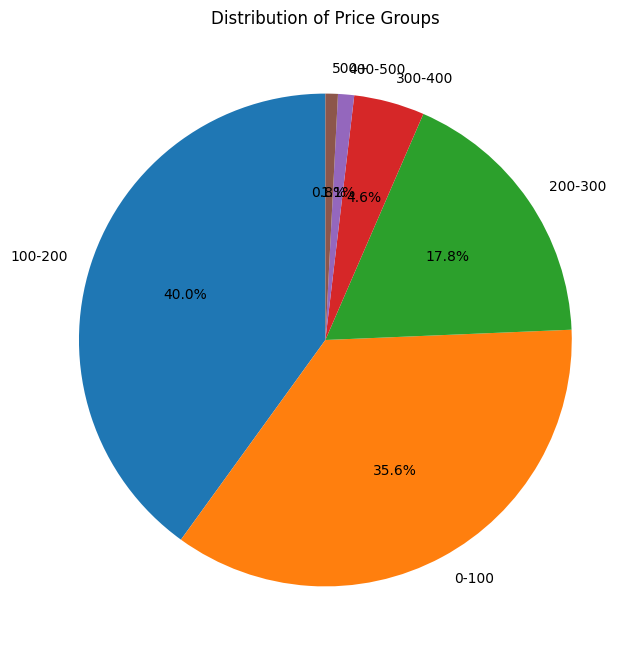

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Create bins for the price ranges
bins = [0, 100, 200, 300, 400, 500, float('inf')]  # Last bin for values above 50
labels = ['0-100', '100-200', '200-300', '300-400', '400-500', '500+']

# Convert 'price' column to numeric, handling errors
df_menu['price'] = pd.to_numeric(df_menu['price'], errors='coerce')

# Cut the price column into groups and assign labels
df_menu['price_group'] = pd.cut(df_menu['price'], bins=bins, labels=labels)

# Get value counts for each group
price_group_counts = df_menu['price_group'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))  # Adjust figure size if needed
plt.pie(price_group_counts, labels=price_group_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Price Groups')
plt.show()

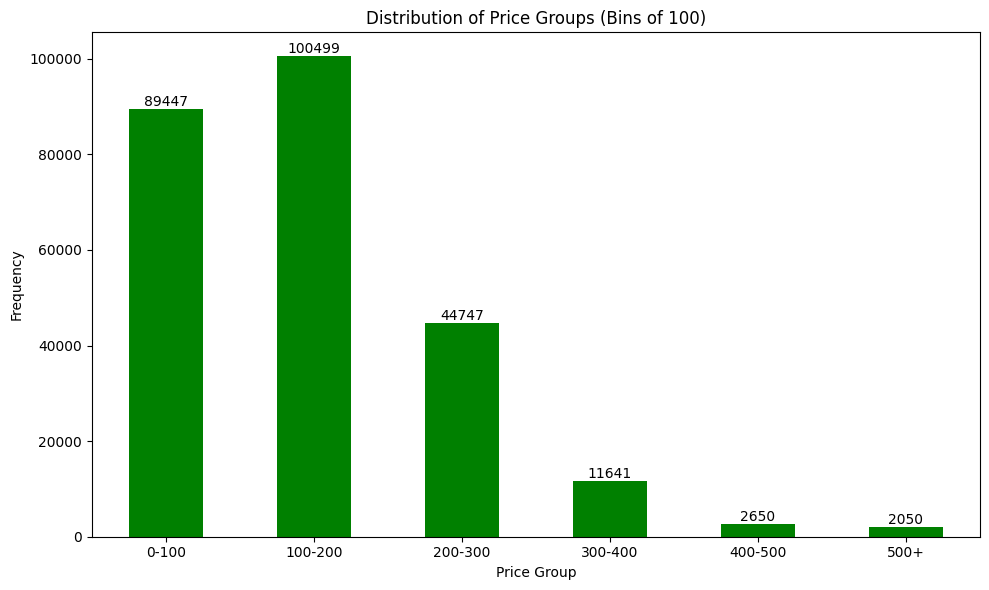

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Create bins for the price ranges with increments of 100
bins = [0, 100, 200, 300, 400, 500, float('inf')]  # Last bin for values above 500
labels = ['0-100', '100-200', '200-300', '300-400', '400-500', '500+']

# Convert 'price' column to numeric, handling errors
df_menu['price'] = pd.to_numeric(df_menu['price'], errors='coerce')

# Cut the price column into groups and assign labels
df_menu['price_group'] = pd.cut(df_menu['price'], bins=bins, labels=labels)

# Get value counts for each group
price_group_counts = df_menu['price_group'].value_counts()

# Reindex the price_group_counts Series to match the order of labels
price_group_counts = price_group_counts.reindex(labels)

# Create the bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
ax = price_group_counts.plot(kind='bar', color='green')  # Store the Axes object

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Distribution of Price Groups (Bins of 100)')
plt.xlabel('Price Group')
plt.ylabel('Frequency')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [32]:
df_menu['f_id'].value_counts()

,count
f_id,
fd1211,3019
fd47270,3019
fd47161,2888
fd28,2888
fd47222,2884
...,...
fd1935,1
fd1932,1
fd1931,1


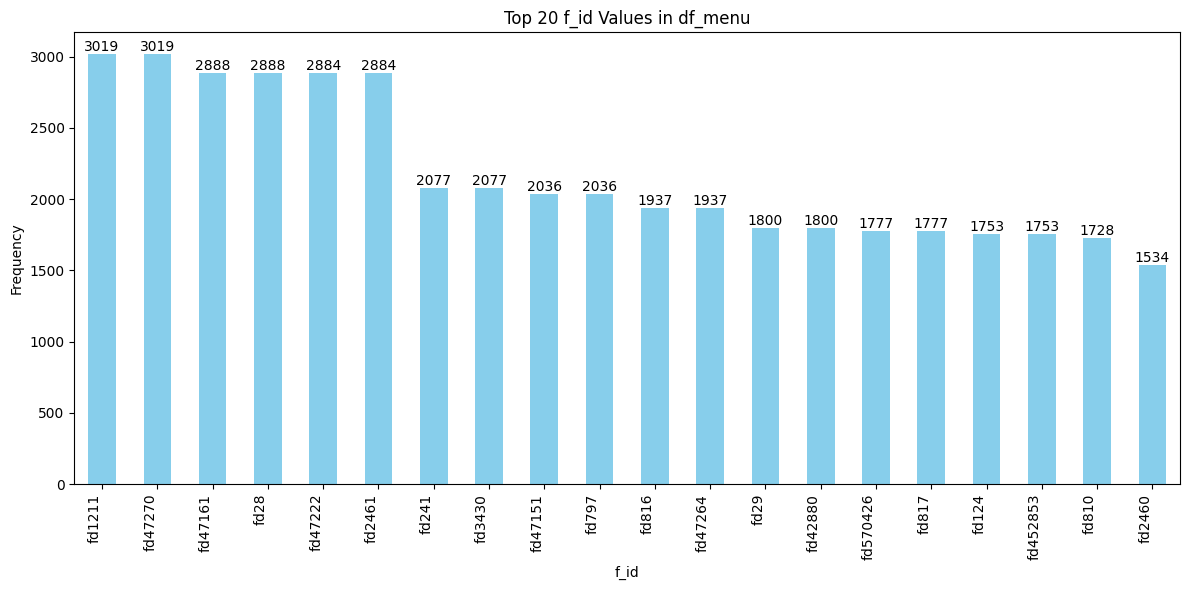

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the top 20 f_id values and their counts
top_20_f_id = df_menu['f_id'].value_counts().head(20)

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
ax = top_20_f_id.plot(kind='bar', color='skyblue')

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Top 20 f_id Values in df_menu')
plt.xlabel('f_id')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

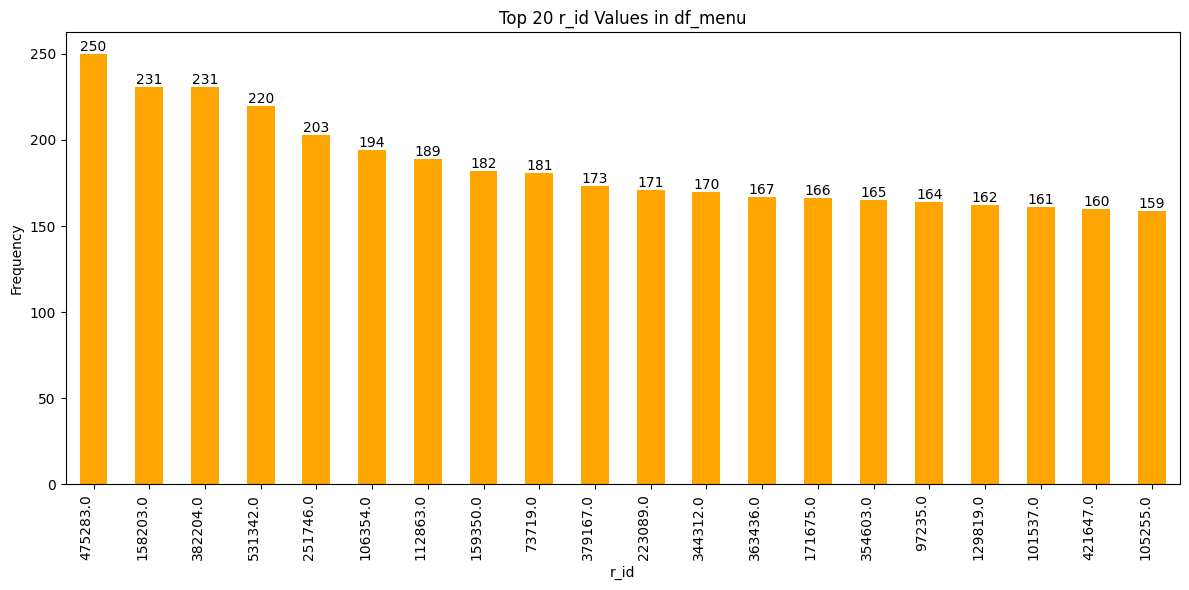

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the top 20 r_id values and their counts
top_20_r_id = df_menu['r_id'].value_counts().head(20)

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
ax = top_20_r_id.plot(kind='bar', color='orange')

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Top 20 r_id Values in df_menu')
plt.xlabel('r_id')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [36]:
df_orders = pd.read_csv('/content/orders.csv')
df_orders.head()

,Unnamed: 0,order_date,sales_qty,sales_amount,currency,user_id,r_id
0,0,2017-10-10,100,41241,INR,49226,567335.0
1,1,2018-05-08,3,-1,INR,77359,531342.0
2,2,2018-04-06,1,875,INR,5321,158203.0
3,3,2018-04-11,1,583,INR,21343,187912.0
4,4,2018-06-18,6,7176,INR,75378,543530.0


In [37]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150281 entries, 0 to 150280
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    150281 non-null  int64  
 1   order_date    150281 non-null  object 
 2   sales_qty     150281 non-null  int64  
 3   sales_amount  150281 non-null  int64  
 4   currency      150281 non-null  object 
 5   user_id       150281 non-null  int64  
 6   r_id          148664 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 8.0+ MB


In [38]:
df_orders.isnull().sum()

,0
Unnamed: 0,0
order_date,0
sales_qty,0
sales_amount,0
currency,0
user_id,0
r_id,1617


In [39]:
df_orders['currency'].value_counts()

,count
currency,
INR\r,150000
INR,279
USD,2


In [40]:
df_orders[df_orders['currency'] == 'USD']

,Unnamed: 0,order_date,sales_qty,sales_amount,currency,user_id,r_id
5,5,2017-11-20,59,500,USD,34323,158204.0
6,6,2017-11-22,36,250,USD,33246,156588.0


In [41]:
df_orders['order_date'].nunique()

806

In [42]:
df_orders['order_date'].value_counts()

,count
order_date,
2018-06-22,378
2018-07-20,344
2018-12-21,343
2018-06-11,335
2017-11-03,331
...,...
2019-09-21,1
2018-05-27,1
2018-11-17,1


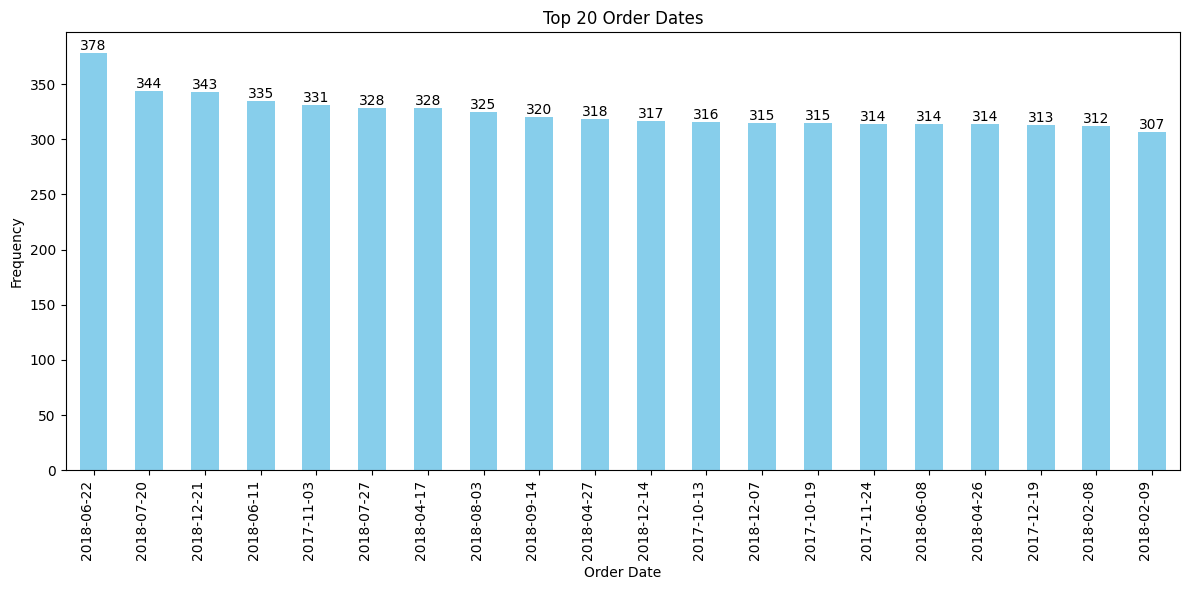

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the top 20 order dates and their counts
top_20_order_dates = df_orders['order_date'].value_counts().head(20)

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
ax = top_20_order_dates.plot(kind='bar', color='skyblue')

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Top 20 Order Dates')
plt.xlabel('Order Date')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

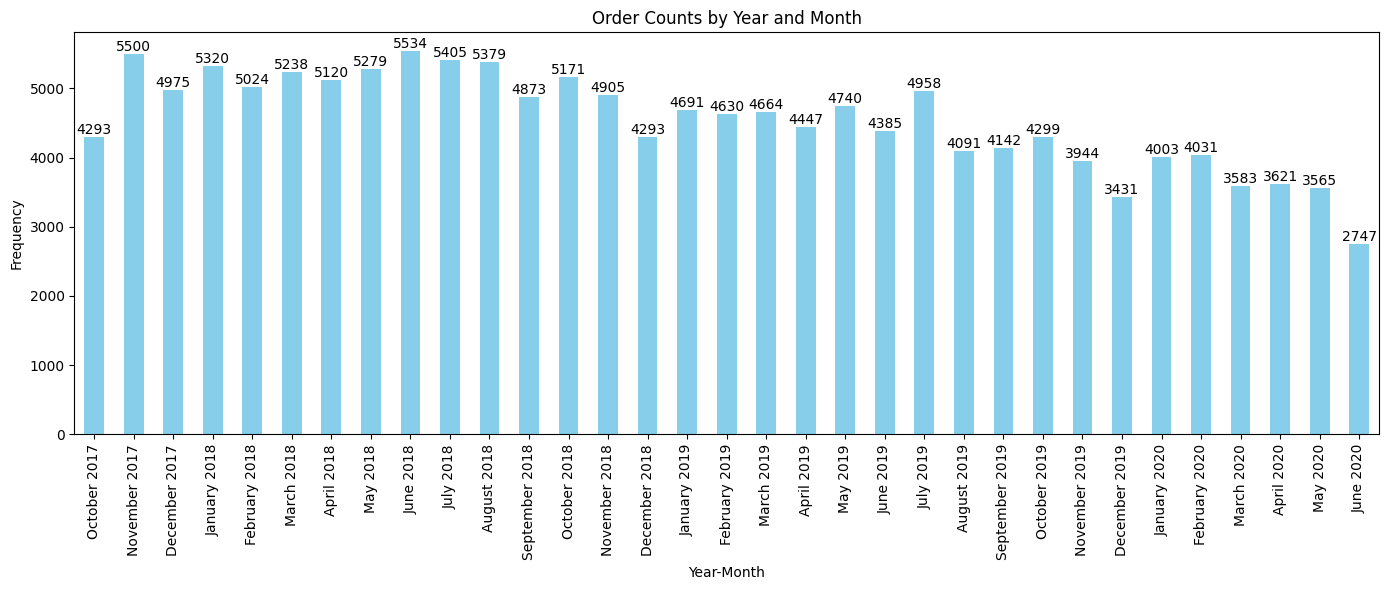

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'order_date' to datetime objects
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Extract year and month and create a new column 'year_month'
df_orders['year_month'] = df_orders['order_date'].dt.strftime('%Y-%m')

# Get the order counts for each year-month
order_counts_by_month = df_orders['year_month'].value_counts().sort_index()

# Create a list of month names for the x-axis labels
month_names = order_counts_by_month.index.map(lambda x: pd.to_datetime(x).strftime('%B %Y'))

# Create the bar chart
plt.figure(figsize=(14, 6))  # Adjust figure size if needed
ax = order_counts_by_month.plot(kind='bar', color='skyblue')

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Order Counts by Year and Month')
plt.xlabel('Year-Month')
plt.ylabel('Frequency')
plt.xticks(range(len(month_names)), month_names, rotation=90, ha='center') # Set x-axis labels to month names
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

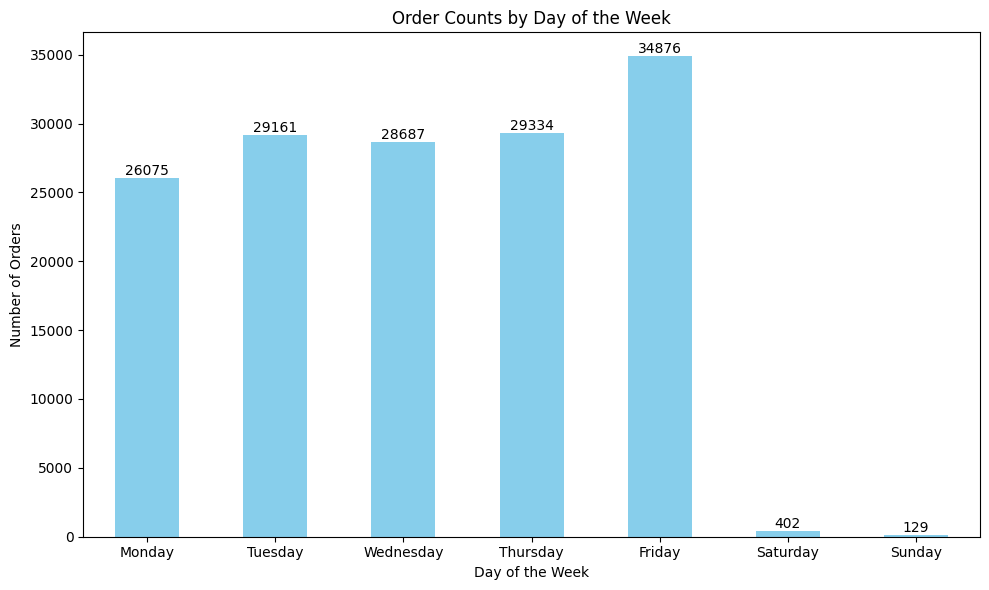

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_orders is your DataFrame
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['day_of_week'] = df_orders['order_date'].dt.day_name()
daily_order_counts = df_orders.groupby('day_of_week')['r_id'].count()

# Order the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_order_counts = daily_order_counts.reindex(day_order)

plt.figure(figsize=(10, 6))
ax = daily_order_counts.plot(kind='bar', color='skyblue')  # Store the Axes object

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Order Counts by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

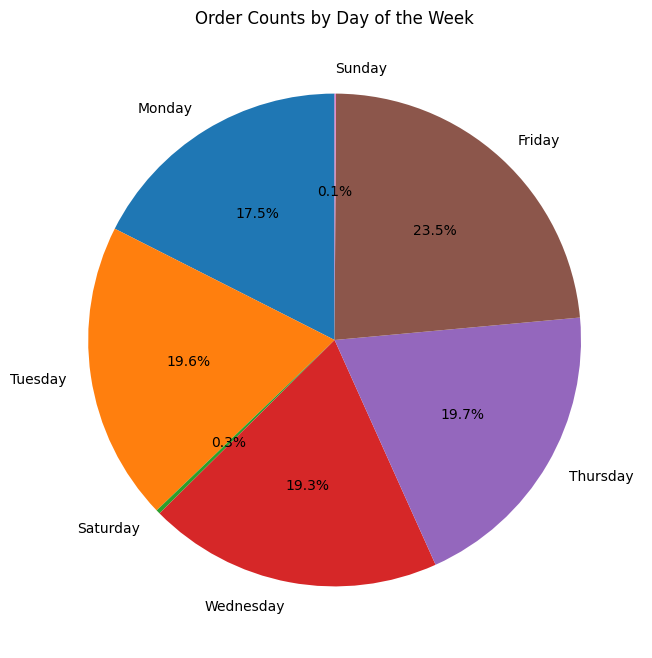

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_orders is your DataFrame
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['day_of_week'] = df_orders['order_date'].dt.day_name()
daily_order_counts = df_orders.groupby('day_of_week')['r_id'].count()

# Order the days of the week
day_order = ['Monday', 'Tuesday','Saturday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
daily_order_counts = daily_order_counts.reindex(day_order)

# Create the pie chart
plt.figure(figsize=(8, 8))  # Adjust figure size if needed
plt.pie(daily_order_counts, labels=daily_order_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Order Counts by Day of the Week')
plt.show()

In [47]:
df_restaurant = pd.read_csv('/content/restaurant.csv')
df_restaurant.head()

,Unnamed: 0,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [48]:
df_restaurant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69686 entries, 0 to 69685
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    69686 non-null  int64 
 1   id            69686 non-null  int64 
 2   name          69672 non-null  object
 3   city          69686 non-null  object
 4   rating        69672 non-null  object
 5   rating_count  69672 non-null  object
 6   cost          69651 non-null  object
 7   cuisine       69667 non-null  object
 8   lic_no        69597 non-null  object
 9   link          69686 non-null  object
 10  address       69671 non-null  object
 11  menu          69685 non-null  object
dtypes: int64(2), object(10)
memory usage: 6.4+ MB


In [49]:
df_restaurant.isnull().sum()

,0
Unnamed: 0,0
id,0
name,14
city,0
rating,14
rating_count,14
cost,35
cuisine,19
lic_no,89
link,0


In [50]:
df_restaurant[df_restaurant.isnull().any(axis=1)]

,Unnamed: 0,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
795,795,301904,SHAKE IT BABY,Agra,--,Too Few Ratings,₹ 200,"Italian,Beverages",NaN,https://www.swiggy.com/restaurants/shake-it-ba...,"SHAKE IT BABY, M/S SHAKE IT BABY SHOP NO-6 SUR...",Menu/301904.json
1299,1299,358634,Meal Factory - By The Healthy Stove,"Vastrapur,Ahmedabad",--,Too Few Ratings,₹ 300,Indian,NaN,https://www.swiggy.com/restaurants/meal-factor...,"Meal Factory - By The Healthy Stove, 'The Heal...",Menu/358634.json
1303,1303,77532,Shiv Shakti Kathiyawadi,"Vastrapur,Ahmedabad",4.1,100+ ratings,₹ 300,Indian,NaN,https://www.swiggy.com/restaurants/shiv-shakti...,"Shiv Shakti Kathiyawadi, 23-24, Ground Floor, ...",Menu/77532.json
4242,4242,93703,Tomato'S,"Chandkheda,Ahmedabad",4.3,100+ ratings,₹ 800,"Mexican,North Indian",NaN,https://www.swiggy.com/restaurants/tomatos-mot...,"Tomato'S, Ground Floor, Shop No. 1, Dwarkesh B...",Menu/93703.json
4966,4966,132295,Chinese Hut,Akola,3.7,50+ ratings,NaN,Chinese,21518145000592,https://www.swiggy.com/restaurants/chinese-hut...,"Chinese Hut, Sindhi Colony, Akola, Maharashtra...",Menu/132295.json
...,...,...,...,...,...,...,...,...,...,...,...,...
67346,67346,31533,Parashar Kitchen,"Old Gurgaon (Zone 6),Gurgaon",4.2,20+ ratings,₹ 300,"Continental,North Indian",NaN,https://www.swiggy.com/restaurants/parashar-ki...,"Parashar Kitchen, shop no 156, sector 4, huda ...",Menu/31533.json
67936,67936,331723,Falhari - A Fruitful Habit,"sohna road,Gurgaon",3.9,100+ ratings,₹ 300,"Healthy Food,Beverages",NaN,https://www.swiggy.com/restaurants/falhari-a-f...,"Falhari - A Fruitful Habit, Shop 1, Village Ba...",Menu/331723.json
68170,68170,175471,Punjabi Swaad,"sohna road,Gurgaon",3.7,50+ ratings,₹ 100,"North Indian,Biryani",NaN,https://www.swiggy.com/restaurants/punjabi-swa...,"Punjabi Swaad, C/o Oyo Town House S1/09,Uppal ...",Menu/175471.json
68415,68415,3774,Sagar Ratna,"sohna road,Gurgaon",3.9,20+ ratings,₹ 450,"South Indian,North Indian",NaN,https://www.swiggy.com/restaurants/sagar-ratna...,"Sagar Ratna, Second Floor, Food court, Airia ...",Menu/3774.json


In [51]:
df_restaurant[(df_restaurant['name'].isnull()) | (df_restaurant['address'].isnull())]

,Unnamed: 0,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
31044,31044,397961,NaN,"Greater Mohali,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/5-tara-grea...,NaN,Menu/397961.json
32912,32912,308071,NaN,"West Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/food-under-...,NaN,Menu/308071.json
33046,33046,308662,NaN,"West Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/franks-frie...,NaN,Menu/308662.json
33488,33488,170889,NaN,"South Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/dhaba-7-pre...,NaN,Menu/170889.json
36492,36492,390394,NaN,"George Town,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/frozen-cafe...,NaN,Menu/390394.json
36544,36544,140189,NaN,"George Town,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/meet-my-bre...,NaN,Menu/140189.json
36723,36723,363495,NaN,"OMR Perungudi,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/food-house-...,NaN,Menu/363495.json
52479,52479,356029,NaN,"South Extension,Delhi",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/mr-pao-sout...,NaN,Menu/356029.json
55920,55920,167737,NaN,"Rohini,Delhi",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/chef-brothe...,NaN,Menu/167737.json
56775,56775,414884,NaN,"Chattarpur,Delhi",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/anardana-ki...,NaN,Menu/414884.json


In [52]:
df_restaurant[(df_restaurant['name'].isnull()) |
              (df_restaurant['address'].isnull()) |
              (df_restaurant['rating'].isnull()) |
              (df_restaurant['rating_count'].isnull())]

,Unnamed: 0,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
31044,31044,397961,NaN,"Greater Mohali,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/5-tara-grea...,NaN,Menu/397961.json
32912,32912,308071,NaN,"West Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/food-under-...,NaN,Menu/308071.json
33046,33046,308662,NaN,"West Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/franks-frie...,NaN,Menu/308662.json
33488,33488,170889,NaN,"South Chd,Chandigarh",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/dhaba-7-pre...,NaN,Menu/170889.json
36492,36492,390394,NaN,"George Town,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/frozen-cafe...,NaN,Menu/390394.json
36544,36544,140189,NaN,"George Town,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/meet-my-bre...,NaN,Menu/140189.json
36723,36723,363495,NaN,"OMR Perungudi,Chennai",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/food-house-...,NaN,Menu/363495.json
52479,52479,356029,NaN,"South Extension,Delhi",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/mr-pao-sout...,NaN,Menu/356029.json
55920,55920,167737,NaN,"Rohini,Delhi",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/chef-brothe...,NaN,Menu/167737.json
56775,56775,414884,NaN,"Chattarpur,Delhi",NaN,NaN,NaN,NaN,NaN,https://www.swiggy.com/restaurants/anardana-ki...,NaN,Menu/414884.json


In [54]:
df_users = pd.read_csv('/content/users.csv')
df_users.head()

,Unnamed: 0,user_id,name,email,password,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size
0,0,1,Claire Ferguson,fordanthony@example.net,NKz0fWDh!5,20,Female,Single,Student,No Income,Post Graduate,4.0
1,1,2,Jennifer Young,ann96@example.com,+i5Q91jt!s,24,Female,Single,Student,Below Rs.10000,Graduate,3.0
2,2,3,Jermaine Roberson,uwalker@example.org,eO4GqGusF(,22,Male,Single,Student,Below Rs.10000,Post Graduate,3.0
3,3,4,Rachel Carpenter,kimberlypatterson@example.net,d^c7O6odaS,22,Female,Single,Student,No Income,Graduate,6.0
4,4,5,Shawn Parker,daniellebennett@example.com,8J#E5RMl1o,22,Male,Single,Student,Below Rs.10000,Post Graduate,4.0


In [55]:
df_restaurant['cost']

,cost
0,₹ 200
1,₹ 200
2,₹ 100
3,₹ 250
4,₹ 250
...,...
69681,₹ 200
69682,₹ 400
69683,₹ 150
69684,₹ 250


In [56]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93309 entries, 0 to 93308
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  93309 non-null  int64  
 1   user_id                     93309 non-null  int64  
 2   name                        93309 non-null  object 
 3   email                       93309 non-null  object 
 4   password                    93309 non-null  object 
 5   Age                         93309 non-null  int64  
 6   Gender                      93309 non-null  object 
 7   Marital Status              93309 non-null  object 
 8   Occupation                  93309 non-null  object 
 9   Monthly Income              93308 non-null  object 
 10  Educational Qualifications  93308 non-null  object 
 11  Family size                 93308 non-null  float64
dtypes: float64(1), int64(3), object(8)
memory usage: 8.5+ MB


In [57]:
df_users.isnull().sum()

,0
Unnamed: 0,0
user_id,0
name,0
email,0
password,0
Age,0
Gender,0
Marital Status,0
Occupation,0
Monthly Income,1
